## Model Distillation

*   **Core Concept:** Model distillation improves efficiency by training a smaller "student" language model (like Qwen3 0.6B) to replicate the intermediate reasoning traces and final answers generated by a massive "teacher" model (like the 671-billion-parameter DeepSeek-R1).
*   **Hard vs. Soft Distillation:** We focus on "hard distillation," which trains the student directly on the teacher's generated text tokens (similar to supervised fine-tuning), because "soft distillation" requires the teacher's full probability distributions, which are computationally expensive and often inaccessible.
*   **Dataset Generation:** The training data is created by feeding 12,000 non-overlapping problems from the MATH dataset to the teacher model to generate synthetic solutions, optionally placing the reasoning steps inside `<think>...</think>` tags.
*   **Data Preparation:** Before training, the synthetic dataset is tokenized, filtered by sequence length (removing excessive outliers over 2,048 tokens) to keep resource requirements manageable, and split into training and validation sets.
*   **Training Objective:** The training relies on an "answer-only cross-entropy loss," meaning the loss is calculated strictly on the teacher's generated answer tokens while the user's input prompt tokens are masked and ignored.
*   **Evaluation and Results:** The student model is trained across multiple epochs (2) using a standard supervised learning loop, and this distillation process successfully improves the base model's accuracy on the MATH-500 test set from 15.2% up to 45.0%.

## Loading Libraries...

In [1]:
from importlib.metadata import version

used_libraries = [
    "reasoning_from_scratch",
    "torch",
    "tokenizers"  # Used by reasoning_from_scratch
]

for lib in used_libraries:
    print(f"{lib} version: {version(lib)}")

reasoning_from_scratch version: 0.1.21
torch version: 2.10.0
tokenizers version: 0.22.2


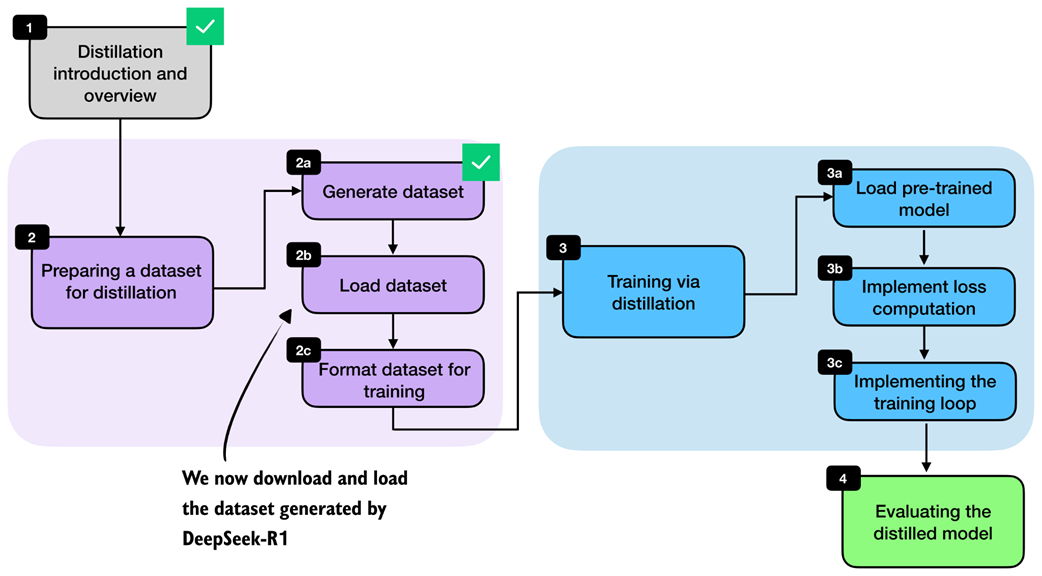

## Preparing DataSet for Distillations

## Load Pre-Generated DataSet

In [2]:
import json
import requests
from pathlib import Path
 
 
def load_distill_data(
    local_path=None,
    partition="deepseek-r1-math-train",
    save_copy=True,
):
 
    if local_path is None:
        local_path = f"{partition}.json"
    local_path = Path(local_path)
 
    url = (
        "https://huggingface.co/datasets/rasbt/math_distill"
        "/resolve/main/data/"
        f"{partition}.json"
    )
    backup_url = (
        "https://f001.backblazeb2.com/file/reasoning-from-scratch/"
        f"MATH/{partition}.json"
    )
 
    if local_path.exists():
        with local_path.open("r", encoding="utf-8") as f:
            data = json.load(f)
 
        size_kb = local_path.stat().st_size / 1e3
        print(f"{local_path}: {size_kb:.1f} KB (cached)")
        return data
 
    assert partition in (
        "deepseek-r1-math-train",
        "deepseek-r1-math500",
        "qwen3-235b-a22b-math-train",
        "qwen3-235b-a22b-math500",
    )
 
    try:
        r = requests.get(url, timeout=30)
        r.raise_for_status()
    except requests.RequestException:
        print("Using backup URL.")
        r = requests.get(backup_url, timeout=30)
        r.raise_for_status()
 
    data = r.json()
 
    if save_copy:
        with local_path.open("w", encoding="utf-8") as f:
            json.dump(data, f, indent=2)
 
        size_kb = local_path.stat().st_size / 1e3
        print(f"{local_path}: {size_kb:.1f} KB")
 
    return data

In [5]:
math_train = load_distill_data(partition="deepseek-r1-math-train")

print("Dataset size:", len(math_train))

deepseek-r1-math-train.json: 107538.0 KB (cached)
Dataset size: 12000


In [6]:
from pprint import pprint

pprint(math_train[4])

{'gtruth_answer': '6',
 'message_content': 'Sam worked \\( x \\) days and did not work \\( y \\) '
                    'days. We know:\n'
                    '\\[\n'
                    'x + y = 20\n'
                    '\\]\n'
                    'His total earnings are calculated as:\n'
                    '\\[\n'
                    '60x - 30y = 660\n'
                    '\\]\n'
                    'Substituting \\( x = 20 - y \\) into the earnings '
                    'equation:\n'
                    '\\[\n'
                    '60(20 - y) - 30y = 660\n'
                    '\\]\n'
                    'Simplifying:\n'
                    '\\[\n'
                    '1200 - 60y - 30y = 660 \\\\\n'
                    '1200 - 90y = 660 \\\\\n'
                    '-90y = 660 - 1200 \\\\\n'
                    '-90y = -540 \\\\\n'
                    'y = \\frac{-540}{-90} = 6\n'
                    '\\]\n'
                    'Sam did not work \\(\\boxed{6}\\) days.',
 'message_t

In [7]:
math_train[4].keys()

dict_keys(['problem', 'gtruth_answer', 'message_thinking', 'message_content'])

## Format Dataset for Training

In [9]:
def format_distilled_answer(entry):
    content = str(entry["message_content"]).strip()
    if not content:
        raise ValueError("Missing non-empty 'message_content' field.")
 
    thinking = str(entry["message_thinking"]).strip()
    return f"<think>{thinking}</think>\n\n{content}"
 


In [10]:
print(format_distilled_answer(math_train[4]))

<think>Okay, let's see. Sam was hired for 20 days. Each day he works, he earns $60, but if he doesn't work a day, they deduct $30 from his earnings. At the end of the 20 days, he got $660. I need to find out how many days he didn't work.

Hmm, so let me think. Let's break this down. Let's say he worked x days and didn't work y days. So total days x + y = 20. That's straightforward. Now, his earnings. For each day worked, he gets $60, so total earnings from working would be 60x. But for each day he didn't work, they subtract $30. Wait, how exactly does that subtraction work? Is it that he loses $30 per day not worked from his total earnings?

Wait, maybe. So if he didn't work y days, then he loses 30*y dollars. But wait, does he get a base salary and then deductions? Or is his total earnings 60x minus 30y?

The problem says, "On days that he works, he earns $60. For each day that he does not work, $30 is subtracted from his earnings." So probably, his total earnings are calculated by 60

In [11]:
from reasoning_from_scratch.ch07 import download_from_github
_ = download_from_github(
    "ch03/02_math500-verifier-scripts/evaluate_json.py"
)

# measure how accurate the teacher model was on this

# After downloading the script via the preceding Python code, we can run it in a code terminal as follows:
# uv run ../evaluation/evaluate_json.py \
# --json_path "deepseek-r1-math-train.json" \
# --gtruth_answer gtruth_answer \
# --generated_text message_content

evaluate_json.py: 3.3 KB (cached)


### Load Tokenizer

In [12]:
from reasoning_from_scratch.qwen3 import (
    download_qwen3_small,
    Qwen3Tokenizer,
)

def load_reasoning_tokenizer(local_dir="qwen3"):
    download_qwen3_small(
        kind="reasoning", tokenizer_only=True, out_dir=local_dir
    )
 
    tokenizer_path = Path(local_dir) / "tokenizer-reasoning.json"
    tokenizer = Qwen3Tokenizer(
        tokenizer_file_path=tokenizer_path,
        # this is to keep the tokenizer style same as the qwen chat and reasoning models
        apply_chat_template=True,
        add_generation_prompt=True,
        add_thinking=True,
    )
 
    return tokenizer
 
tokenizer = load_reasoning_tokenizer()
 

✓ qwen3/tokenizer-reasoning.json already up-to-date


In [13]:
prompt = "Sam is hired for a 20-day period..."
prompt_ids = tokenizer.encode(prompt)
decoded_prompt = tokenizer.decode(prompt_ids)
print(decoded_prompt)

<|im_start|>user
Sam is hired for a 20-day period...<|im_end|>
<|im_start|>assistant



In [27]:
# contains reasoning trace and ground truth
answer = (
    "<think>Okay, let me try to solve "
    "this problem...</think> \\boxed{4}"
)
# answer_ids = tokenizer.encode(answer, chat_wrapped=True) # assistant start tokens
answer_ids = tokenizer.encode(answer, chat_wrapped=False)
decoded_answer = tokenizer.decode(answer_ids)


In [25]:
# chat_wrapped=True
print(decoded_answer)

<|im_start|>user
<think>Okay, let me try to solve this problem...</think> \boxed{4}<|im_end|>
<|im_start|>assistant



In [28]:
# chat_wrapped=False
print(decoded_answer)

<think>Okay, let me try to solve this problem...</think> \boxed{4}


In [30]:
token_ids = prompt_ids + answer_ids + [tokenizer.eos_token_id]
decoded_token_ids = tokenizer.decode(token_ids)
print(decoded_token_ids)

<|im_start|>user
Sam is hired for a 20-day period...<|im_end|>
<|im_start|>assistant
<think>Okay, let me try to solve this problem...</think> \boxed{4}<|im_end|>


In [31]:
token_ids

[151644,
 872,
 198,
 23950,
 374,
 21446,
 369,
 264,
 220,
 17,
 15,
 11228,
 4168,
 1112,
 151645,
 198,
 151644,
 77091,
 198,
 151667,
 32313,
 11,
 1077,
 752,
 1430,
 311,
 11625,
 419,
 3491,
 1112,
 151668,
 1124,
 79075,
 90,
 19,
 92,
 151645]

### Formatting and tokenizing the whole dataset

In [22]:
from reasoning_from_scratch.ch03 import render_prompt

def build_examples(data, tokenizer):
    examples = []
    skipped = 0
 
    for entry in data:
        try:
            # Step 1: Render the problem in the chat format
            prompt = render_prompt(entry["problem"])
            prompt_ids = tokenizer.encode(prompt)
 
            # Step 2: Tokenize the teacher reasoning trace and final answer
            target_answer = format_distilled_answer(entry)
            answer_ids = tokenizer.encode(
                target_answer, chat_wrapped=False
            )
         
            # Step 3: Combine prompt and answer for training
            token_ids = (
                prompt_ids + answer_ids + [tokenizer.eos_token_id]
            )
 
            if len(token_ids) < 2:
                skipped += 1
                continue
 
            # Store prompt length so we can ignore  
            # prompt tokens in the loss later
            examples.append({
                "token_ids": token_ids,
                "prompt_len": len(prompt_ids),
            })
        except (KeyError, TypeError, ValueError):
            # Skip misformatted examples
            skipped += 1
 
    return examples, skipped


In [18]:
examples, skipped = build_examples(math_train, tokenizer)
 
print("Number of examples:", len(examples))
print("Number of skipped examples:", skipped)

Number of examples: 12000
Number of skipped examples: 0


#### Examples

In [34]:
print(f"#token_ids: {examples[4]["token_ids"]}")

#token_ids: [151644, 872, 198, 2610, 525, 264, 10950, 6888, 17847, 624, 16141, 279, 3405, 323, 3270, 279, 1590, 1102, 389, 264, 501, 1555, 438, 510, 59, 79075, 90, 11692, 39351, 630, 14582, 510, 23950, 374, 21446, 369, 264, 220, 17, 15, 11228, 4168, 13, 1913, 2849, 429, 566, 4278, 11, 566, 63759, 57960, 14085, 21, 15, 13, 1752, 1817, 1899, 429, 566, 1558, 537, 975, 11, 57960, 14085, 18, 15, 374, 32256, 291, 504, 806, 23681, 13, 2411, 279, 835, 315, 279, 220, 17, 15, 11228, 4168, 11, 566, 3949, 57960, 14085, 21, 21, 15, 13, 2585, 1657, 2849, 1521, 566, 537, 975, 1939, 16141, 25, 151645, 198, 151644, 77091, 198, 151667, 32313, 11, 1077, 594, 1490, 13, 8224, 572, 21446, 369, 220, 17, 15, 2849, 13, 8886, 1899, 566, 4278, 11, 566, 63759, 400, 21, 15, 11, 714, 421, 566, 3171, 944, 975, 264, 1899, 11, 807, 36810, 400, 18, 15, 504, 806, 23681, 13, 2411, 279, 835, 315, 279, 220, 17, 15, 2849, 11, 566, 2684, 400, 21, 21, 15, 13, 358, 1184, 311, 1477, 700, 1246, 1657, 2849, 566, 3207, 944, 975, 3

In [19]:
print(tokenizer.decode(examples[4]["token_ids"]))

<|im_start|>user
You are a helpful math assistant.
Answer the question and write the final result on a new line as:
\boxed{ANSWER}

Question:
Sam is hired for a 20-day period. On days that he works, he earns $\$$60. For each day that he does not work, $\$$30 is subtracted from his earnings. At the end of the 20-day period, he received $\$$660. How many days did he not work?

Answer:<|im_end|>
<|im_start|>assistant
<think>Okay, let's see. Sam was hired for 20 days. Each day he works, he earns $60, but if he doesn't work a day, they deduct $30 from his earnings. At the end of the 20 days, he got $660. I need to find out how many days he didn't work.

Hmm, so let me think. Let's break this down. Let's say he worked x days and didn't work y days. So total days x + y = 20. That's straightforward. Now, his earnings. For each day worked, he gets $60, so total earnings from working would be 60x. But for each day he didn't work, they subtract $30. Wait, how exactly does that subtraction work? I

## Filtering and Splitting the Dataset

* filter long sequences, To keep the computational costs reasonable
* split the dataset into training and validation subsets

### Helper function to analyze sequence length

In [20]:
def compute_length(examples, answer_only=False):
    lengths = []
    for ex in examples:
        total = len(ex["token_ids"])
        length = total - ex["prompt_len"] if answer_only else total
        lengths.append(length)
 
    avg_len = round(sum(lengths) / len(lengths))
 
    shortest_len = min(lengths)
    longest_len = max(lengths)
    shortest_idx = lengths.index(shortest_len)
    longest_idx = lengths.index(longest_len)
 
    print(f"Average: {avg_len} tokens")
    print(f"Shortest: {shortest_len} tokens (index {shortest_idx})")
    print(f"Longest: {longest_len} tokens (index {longest_idx})")
 


In [21]:
compute_length(examples)

Average: 2946 tokens
Shortest: 236 tokens (index 10846)
Longest: 42005 tokens (index 2529)


### Filtering Long Examples

In [36]:
def filter_examples_by_max_len(examples, max_len=2048):
    filtered_examples = [
        s for s in examples
        if len(s["token_ids"]) <= max_len
    ]
 
    print("Original:", len(examples))
    print("Filtered:", len(filtered_examples))
    print("Removed:", len(examples) - len(filtered_examples))
 
    return filtered_examples
 

In [37]:
filtered_examples = filter_examples_by_max_len(examples, max_len=2048)

Original: 12000
Filtered: 6695
Removed: 5305


In [38]:
compute_length(filtered_examples)

Average: 1180 tokens
Shortest: 236 tokens (index 5971)
Longest: 2048 tokens (index 5587)


### Partitioning into training and validation sets

In [39]:
import random
 
rng = random.Random(123)
rng.shuffle(filtered_examples)
 
train_examples = filtered_examples[25:]
val_examples = filtered_examples[:25]
 
print("Number of train examples:", len(train_examples))
print("Number of validation examples:", len(val_examples))
 

Number of train examples: 6670
Number of validation examples: 25


### Check weather training and validation examples are balanced

In [40]:
compute_length(train_examples)

Average: 1180 tokens
Shortest: 236 tokens (index 5730)
Longest: 2048 tokens (index 1319)


In [41]:
compute_length(val_examples)

Average: 1106 tokens
Shortest: 481 tokens (index 15)
Longest: 1918 tokens (index 12)


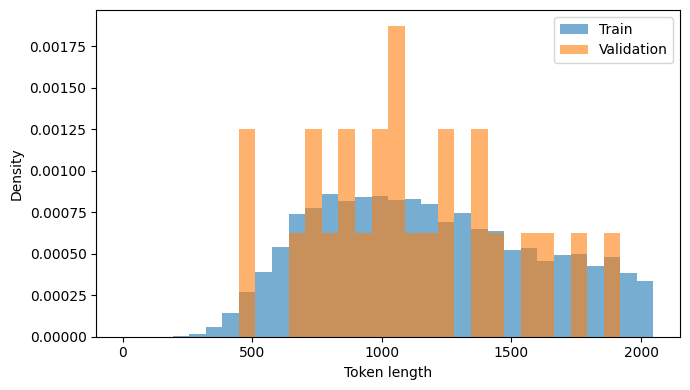

In [49]:
import matplotlib.pyplot as plt

train_lengths = [len(ex["token_ids"]) for ex in train_examples]
val_lengths = [len(ex["token_ids"]) for ex in val_examples]

# Normalize counts because the validation split is much smaller
bins = range(0, max(train_lengths + val_lengths) + 64, 64)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(train_lengths, bins=bins, density=True, alpha=0.6, label="Train")
ax.hist(val_lengths, bins=bins, density=True, alpha=0.6, label="Validation")
ax.set_xlabel("Token length")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()

## Training Via Distillation

### Load Pre-Trained Model 

In [46]:
import torch
 
from reasoning_from_scratch.ch02 import get_device
from reasoning_from_scratch.ch03 import (
    load_model_and_tokenizer,
)
 
device = get_device()
 
model, _ = load_model_and_tokenizer(
    which_model="base",
    device=device,
    use_compile=False,
)
 

Using Apple Silicon GPU (MPS)
✓ qwen3/qwen3-0.6B-base.pth already up-to-date


In [50]:
# Pick the shortest token example
token_ids = train_examples[5730]["token_ids"]
prompt_len = train_examples[5730]["prompt_len"]
print(f"#token_ids: {token_ids} \n#prompt_len : {prompt_len}")

#token_ids: [151644, 872, 198, 2610, 525, 264, 10950, 6888, 17847, 624, 16141, 279, 3405, 323, 3270, 279, 1590, 1102, 389, 264, 501, 1555, 438, 510, 59, 79075, 90, 11692, 39351, 630, 14582, 510, 46254, 400, 4080, 19, 24, 10699, 611, 220, 22, 3, 382, 16141, 25, 151645, 198, 151644, 77091, 198, 151667, 32313, 11, 1077, 594, 1490, 13, 358, 1184, 311, 12564, 481, 19, 24, 17779, 553, 220, 22, 13, 88190, 11, 12804, 448, 8225, 5109, 2677, 22466, 752, 705, 264, 2699, 13, 13824, 11, 279, 5912, 374, 429, 264, 8225, 17779, 553, 264, 6785, 6696, 264, 8225, 1102, 11, 1290, 30, 2055, 11, 1156, 11, 358, 3278, 1101, 21749, 220, 19, 24, 553, 220, 22, 11, 892, 374, 220, 22, 13, 5005, 3796, 279, 8225, 1841, 13, 2055, 432, 1265, 387, 481, 22, 13, 6771, 752, 1990, 15934, 13, 220, 22, 3039, 220, 22, 374, 220, 19, 24, 11, 773, 220, 19, 24, 17779, 553, 220, 22, 374, 220, 22, 13, 8704, 279, 4024, 1372, 572, 8225, 11, 49702, 553, 264, 6785, 3643, 279, 4226, 8225, 13, 84194, 11, 429, 3643, 5530, 13, 358, 1744, 4

### Loss Computation - Calculate Cross Entropy

* Cross-entropy loss provide the training signal 
* Cross-entropy is simply the negative average of token log-probabilities
* target class we want to predict at each position is the next token in the teacher-generated sequence
* log-probability measures how much probability the model assigns to the correct next token
* Higher log-probability means the model is more confident in the correct token, and vice-versa

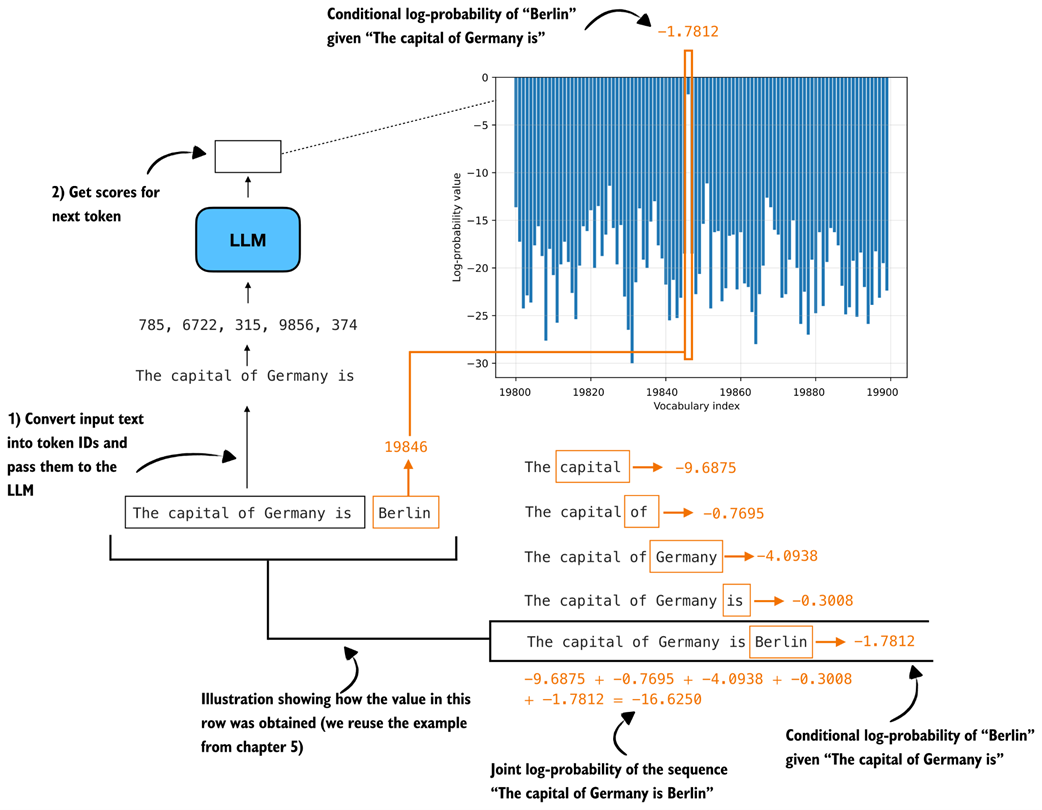

#### Using sequence_logprob

In [51]:
tok = torch.tensor(token_ids, dtype=torch.long, device=device)

In [52]:
from reasoning_from_scratch.ch06 import sequence_logprob

with torch.no_grad():
    seq_logprob = sequence_logprob(model, tok, prompt_len)
    num_answer_tokens = tok.numel() - prompt_len
    avg_logprob = -seq_logprob / num_answer_tokens
print(f"Average logprob: {avg_logprob:.2f}")
 

Average logprob: 1.68


#### Using PyTorch's cross-entropy

In [54]:
# Shift the sequence by one token so each input predicts the next token target
input_ids = tok[:-1].unsqueeze(0)
target_ids = tok[1:]
logits = model(input_ids).squeeze(0)
 
# Drop the prompt positions so the loss only covers the teacher answer
first_answer_logit_idx = max(prompt_len - 1, 0)
answer_logits = logits[first_answer_logit_idx:]
answer_targets = target_ids[first_answer_logit_idx:]
 
# Compute cross-entropy loss
with torch.no_grad():
    ce_mean_direct = torch.nn.functional.cross_entropy(
        answer_logits, answer_targets
    )
print(f"Cross-entropy: {ce_mean_direct:.2f}")
 

Cross-entropy: 1.68


#### torch refresher

In [56]:
import torch
x = torch.zeros(2, 1, 3, 1)
print(x)
print(x.squeeze().shape)      # Output: torch.Size([2, 3])
print(x.squeeze(dim=1).shape) # Output: torch.Size([2, 3, 1])

tensor([[[[0.],
          [0.],
          [0.]]],


        [[[0.],
          [0.],
          [0.]]]])
torch.Size([2, 3])
torch.Size([2, 3, 1])


In [57]:
import torch
x = torch.tensor([1, 2, 3])   # Shape: torch.Size([3])
print(x)
print(x.unsqueeze(0).shape)   # Output: torch.Size([1, 3])
print(x.unsqueeze(1).shape)   # Output: torch.Size([3, 1])


tensor([1, 2, 3])
torch.Size([1, 3])
torch.Size([3, 1])


#### function that calculates the answer-only loss for a single example

In [55]:
def compute_example_loss(model, example, device):
    token_ids = example["token_ids"]
    prompt_len = example["prompt_len"]
 
    # Create input-target pairs that are shifted by one token
    input_ids = torch.tensor(
        token_ids[:-1], dtype=torch.long, device=device
    ).unsqueeze(0)
    target_ids = torch.tensor(
        token_ids[1:], dtype=torch.long, device=device
    )
 
    logits = model(input_ids).squeeze(0)
 
    # Ignore prompt tokens so the loss is computed on the distilled answer only
    answer_start = max(prompt_len - 1, 0)
    answer_logits = logits[answer_start:]
    answer_targets = target_ids[answer_start:]
 
    # Compute cross-entropy loss
    loss = torch.nn.functional.cross_entropy(
        answer_logits, answer_targets
    )
    return loss
 

In [56]:
# Use to verify that the helper returns the same loss as before
with torch.no_grad():
    loss = compute_example_loss(
        model, train_examples[5730], device
    )
 
print(f"Loss: {loss:.2f}")

Loss: 1.68


In [57]:
train_examples[:3]

[{'token_ids': [151644,
   872,
   198,
   2610,
   525,
   264,
   10950,
   6888,
   17847,
   624,
   16141,
   279,
   3405,
   323,
   3270,
   279,
   1590,
   1102,
   389,
   264,
   501,
   1555,
   438,
   510,
   59,
   79075,
   90,
   11692,
   39351,
   630,
   14582,
   510,
   17949,
   315,
   2518,
   8391,
   287,
   11,
   31392,
   12592,
   6022,
   594,
   38048,
   7172,
   311,
   220,
   20,
   24,
   23,
   4143,
   13,
   1096,
   374,
   458,
   5263,
   315,
   400,
   19,
   59,
   4,
   3,
   916,
   1537,
   1042,
   594,
   38048,
   13,
   3555,
   572,
   1537,
   1042,
   594,
   38048,
   1939,
   16141,
   25,
   151645,
   198,
   151644,
   77091,
   198,
   151667,
   32313,
   11,
   773,
   279,
   3491,
   374,
   911,
   9271,
   1537,
   1042,
   594,
   38048,
   518,
   31392,
   12592,
   6022,
   1573,
   279,
   220,
   19,
   4,
   5263,
   429,
   6069,
   311,
   220,
   20,
   24,
   23,
   4143,
   419,
   1042,
   13,
   88190,


#### Evaluating loss across multiple examples

Goal: Reduce Loss

* Training loss is often noisy because it fluctuates during the active optimization of training examples. 
* Validation loss is instead calculated on a separate, held-out dataset without changing the model's weights. 

Consequently, validation loss is a more reliable metric because it provides a cleaner signal of whether the model's learning actually generalizes.

In [58]:
@torch.no_grad()
def evaluate_examples(model, examples, device):
    was_training = model.training
    
    # Temporarily switch to evaluation mode while scoring the examples
    model.eval()
    total_loss = 0.0
    num_examples = 0
 
    # Sum the loss over all examples
    for example in examples:
        loss = compute_example_loss(model, example, device)
        total_loss += loss.item()
        num_examples += 1
 
    # Restore training mode so this helper is safe to call during training
    if was_training:
        model.train()
 
    # Average the loss over all examples
    return total_loss / num_examples 

In [59]:
# Estimate the current training loss on a small subset
train_loss = evaluate_examples(model, train_examples[:3], device)
print(f"Train loss (3 examples): {train_loss:.2f}")

Train loss (3 examples): 0.98


In [60]:
val_loss = evaluate_examples(model, val_examples[:3], device)
print(f"Validation loss (3 examples): {val_loss:.2f}")

Validation loss (3 examples): 1.02


### Training Loop for Distillation

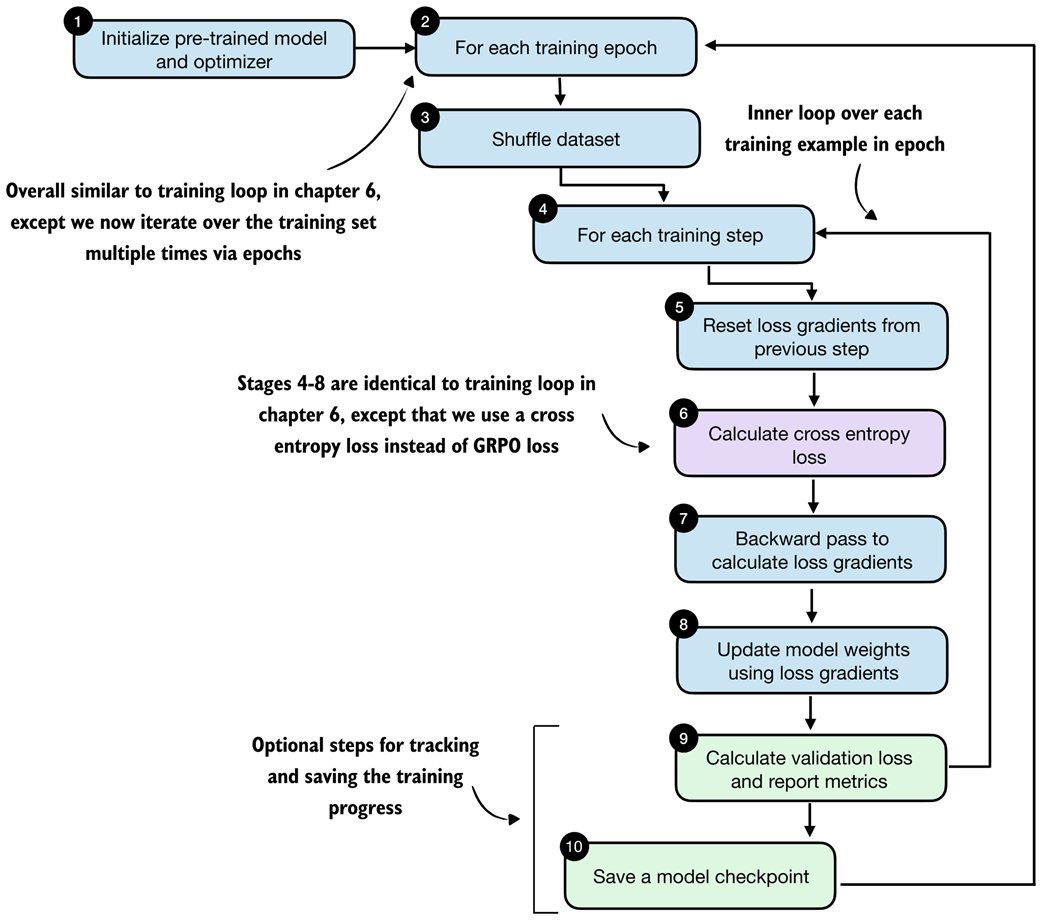

In [61]:
import time

def train_distillation(
    model,
    train_examples,
    val_examples,
    device,
    epochs=2,
    lr=5e-6,
    grad_clip_norm=None,
    seed=123,
    log_every=50,
    checkpoint_dir="checkpoints",
    csv_log_path=None,
):
    # Step 1: initialize optimizer (model is already loaded)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    model.train()
 
    total_steps = epochs * len(train_examples)
    global_step = 0
    rng = random.Random(seed)
 
    if csv_log_path is None:
        timestamp = time.strftime("%Y%m%d_%H%M%S")
        csv_log_path = f"train_distill_metrics_{timestamp}.csv"
    csv_log_path = Path(csv_log_path)
 
    # Step 2: iterate over training epochs
    for epoch in range(1, epochs + 1):
        
        # Step 3: shuffle the training examples at the start of the epoch
        epoch_examples = list(train_examples)
        rng.shuffle(epoch_examples)
 
        # Step 4: iterate over training examples in epoch
        for example in epoch_examples:
            global_step += 1
 
            # Stage 5: reset loss gradient
            optimizer.zero_grad()
 
            # Step 6: compute the cross-entropy loss for the current example
            loss = compute_example_loss(model, example, device)
 
            # Step 7: backpropagate gradients
            loss.backward()
 
            # Optionally clip large gradients to improve training stability
            if grad_clip_norm is not None:
                torch.nn.utils.clip_grad_norm_(
                    model.parameters(), grad_clip_norm
                )
 
            # Step 8: update the model weights
            optimizer.step()
 
            # Step 9: periodically evaluate the current model on the validation set
            if log_every and global_step % log_every == 0:
                val_loss = evaluate_examples(
                    model=model,
                    examples=val_examples,
                    device=device,
                )
                model.train()
                print(
                    f"[Epoch {epoch}/{epochs} "
                    f"Step {global_step}/{total_steps}] "
                    f"train_loss={loss.item():.4f} "
                    f"val_loss={val_loss:.4f}"
                )
                append_csv_metrics(
                    csv_log_path=csv_log_path,
                    epoch_idx=epoch,
                    total_steps=global_step,
                    train_loss=loss.item(),
                    val_loss=val_loss,
                )
 
        # Step 10: record the metrics and save a checkpoint for this epoch
        ckpt_path = save_checkpoint(
            model=model,
            checkpoint_dir=checkpoint_dir,
            step=global_step,
            suffix=f"epoch{epoch}",
        )
        print(f"Saved checkpoint to {ckpt_path}")
    return model
 
 
def save_checkpoint(model, checkpoint_dir, step, suffix=""):
    checkpoint_dir = Path(checkpoint_dir)
    checkpoint_dir.mkdir(parents=True, exist_ok=True)
    suffix = f"-{suffix}" if suffix else ""
    ckpt_path = (
        checkpoint_dir /
        f"qwen3-0.6B-distill-step{step:05d}{suffix}.pth"
    )
    torch.save(model.state_dict(), ckpt_path)
    return ckpt_path
 
 
def append_csv_metrics(
    csv_log_path,
    epoch_idx,
    total_steps,
    train_loss,
    val_loss,
):
    if not csv_log_path.exists():
        csv_log_path.write_text(
            "epoch,total_steps,train_loss,val_loss\n",
            encoding="utf-8",
        )
    with csv_log_path.open("a", encoding="utf-8") as f:
        f.write(
            f"{epoch_idx},{total_steps},{train_loss:.6f},"
            f"{val_loss:.6f}\n"
        )
 

#### Execute on 10 examples

In [62]:
# Seed PyTorch so the short demo is reproducible
torch.manual_seed(0)
 
train_distillation(
    model,
    # Train on a tiny subset so this notebook run stays lightweight
    train_examples=train_examples[:10],
    val_examples=val_examples[:10],
    device=device,
    epochs=2,
    lr=5e-6, # reasonable for fine-tuning pre-trained model
    grad_clip_norm=1.0, # prevent unstable updates when a particular example produces unusually large gradients
    seed=123,
    log_every=5,
    csv_log_path="../metrics/train_distill_metrics.csv",
)
 

[Epoch 1/2 Step 5/20] train_loss=0.9688 val_loss=0.9074
[Epoch 1/2 Step 10/20] train_loss=0.9844 val_loss=0.8863
Saved checkpoint to checkpoints/qwen3-0.6B-distill-step00010-epoch1.pth
[Epoch 2/2 Step 15/20] train_loss=0.8047 val_loss=0.8707
[Epoch 2/2 Step 20/20] train_loss=0.7148 val_loss=0.8586
Saved checkpoint to checkpoints/qwen3-0.6B-distill-step00020-epoch2.pth


Qwen3Model(
  (tok_emb): Embedding(151936, 1024)
  (trf_blocks): ModuleList(
    (0-27): 28 x TransformerBlock(
      (att): GroupedQueryAttention(
        (W_query): Linear(in_features=1024, out_features=2048, bias=False)
        (W_key): Linear(in_features=1024, out_features=1024, bias=False)
        (W_value): Linear(in_features=1024, out_features=1024, bias=False)
        (out_proj): Linear(in_features=2048, out_features=1024, bias=False)
        (q_norm): RMSNorm()
        (k_norm): RMSNorm()
      )
      (ff): FeedForward(
        (fc1): Linear(in_features=1024, out_features=3072, bias=False)
        (fc2): Linear(in_features=1024, out_features=3072, bias=False)
        (fc3): Linear(in_features=3072, out_features=1024, bias=False)
      )
      (norm1): RMSNorm()
      (norm2): RMSNorm()
    )
  )
  (final_norm): RMSNorm()
  (out_head): Linear(in_features=1024, out_features=151936, bias=False)
)

In [71]:
from reasoning_from_scratch.ch07 import download_from_github
download_from_github(
    "ch08/04_train_with_distillation/distill.py"
)

distill.py: 14.6 KB


In [72]:
import sys
print(sys.executable)

/Users/nikhilgupta/gitPersonal/reasoning/venv-reasoning/bin/python3


In [73]:
download_from_github(
    "ch08/03_logs/deepseek-r1-2048_distill_metrics.csv"
)

deepseek-r1-2048_distill_metrics.csv: 10.3 KB


In [70]:
import pandas as pd

df = pd.read_csv('../metrics/deepseek-r1-2048_distill_metrics.csv')

# View the first few rows
print(df.head())
# print(df[:10])
print(df[200:205])


   epoch  total_steps  train_loss  val_loss
0      1           50    0.765625  0.698918
1      1          100    0.746094  0.667668
2      1          150    0.628906  0.648287
3      1          200    0.722656  0.636418
4      1          250    0.683594  0.627554
     epoch  total_steps  train_loss  val_loss
200      2        10000    0.384766  0.538161
201      2        10050    0.765625  0.538912
202      2        10100    0.617188  0.538912
203      2        10150    0.449219  0.539814
204      2        10200    0.601562  0.538912


In [63]:
print(pd.options.display.max_rows) 

60


## Plotting distillation losses from a CSV log

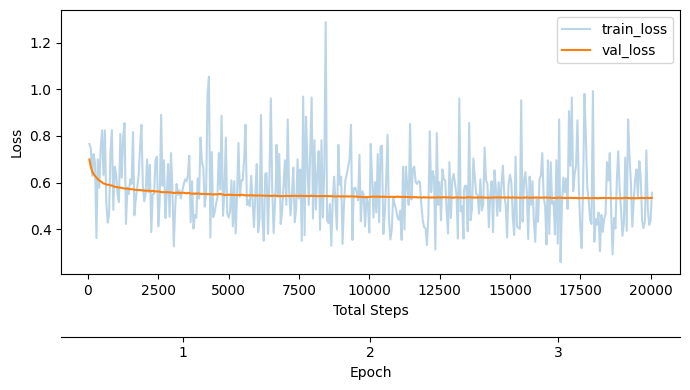

In [74]:
import csv
import matplotlib.pyplot as plt
 
 
def plot_distill_metrics(csv_path="../metrics/train_distill_metrics.csv"):
    total_steps, train_losses, val_losses, epoch_bounds = [], [], [], {}
 

    with open(csv_path, newline="", encoding="utf-8") as f:
        for row in csv.DictReader(f):
            step = int(row["total_steps"])
            epoch = int(row["epoch"])
            total_steps.append(step)
            train_losses.append(float(row["train_loss"]))
            val_losses.append(float(row["val_loss"]))
            epoch_bounds.setdefault(epoch, [step, step])[1] = step
 
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(total_steps, train_losses, label="train_loss", alpha=0.3)
    ax.plot(total_steps, val_losses, label="val_loss")
    ax.set_xlabel("Total Steps")
    ax.set_ylabel("Loss")
    ax.legend()
 

    epoch_axis = ax.secondary_xaxis("bottom")
    epoch_axis.spines["bottom"].set_position(("outward", 45))
    epochs = sorted(epoch_bounds)
    epoch_axis.set_xticks(
        [
            (epoch_bounds[epoch][0] + epoch_bounds[epoch][1]) / 2
            for epoch in epochs
        ]
    )
    epoch_axis.set_xticklabels(epochs)
    epoch_axis.set_xlabel("Epoch")
 
    plt.tight_layout()
    plt.show()
 
 
plot_distill_metrics("../metrics/deepseek-r1-2048_distill_metrics.csv")

<!-- Validation loss is considered a more reliable metric to watch during distillation because it is **computed on a separate, held-out validation set without updating the model's weights**. This provides a **cleaner signal of whether the student model's learning actually generalizes** beyond the specific data it is trained on. 

In contrast, the training loss is measured directly on the examples actively being optimized at the current training step. Because it is affected by the specific order of the samples and the immediate parameter updates taking place, **the training loss is inherently noisier and can fluctuate significantly**. By evaluating a fixed set of examples, the validation loss avoids these fluctuations and produces a less noisy, more informative curve for tracking the model's true progress. -->

## Why Validation loss is preferred training signal?

Validation loss is considered a more reliable metric to watch during distillation because it is **computed on a separate, held-out validation set without updating the model's weights**. This provides a **cleaner signal of whether the student model's learning actually generalizes** beyond the specific data it is trained on. 

In contrast, the training loss is measured directly on the examples actively being optimized at the current training step. Because it is affected by the specific order of the samples and the immediate parameter updates taking place, **the training loss is inherently noisier and can fluctuate significantly**. By evaluating a fixed set of examples, the validation loss avoids these fluctuations and produces a less noisy, more informative curve for tracking the model's true progress.

## Evaluation on MATH-500 test set

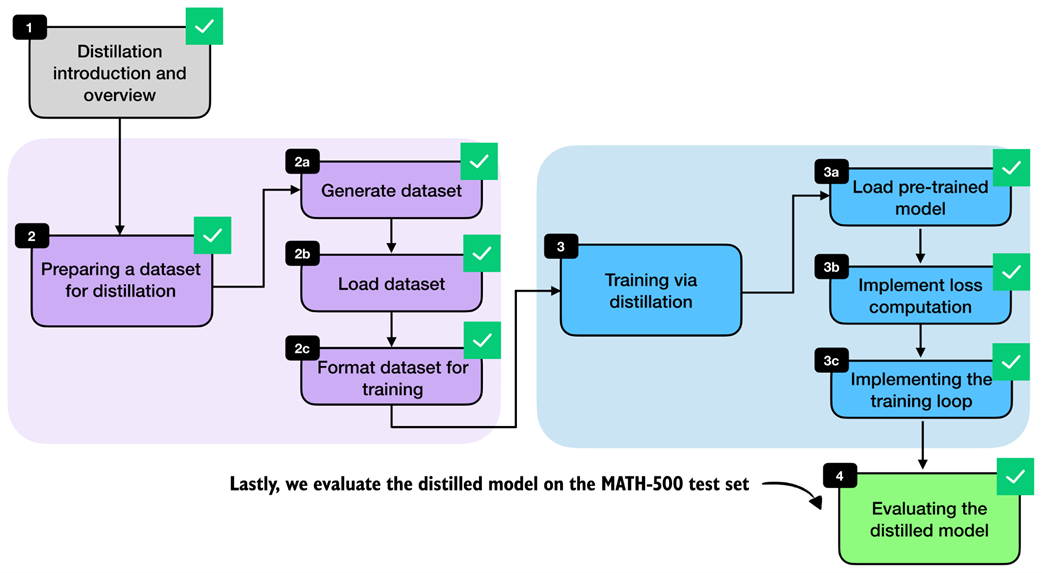

## Evaluation Results

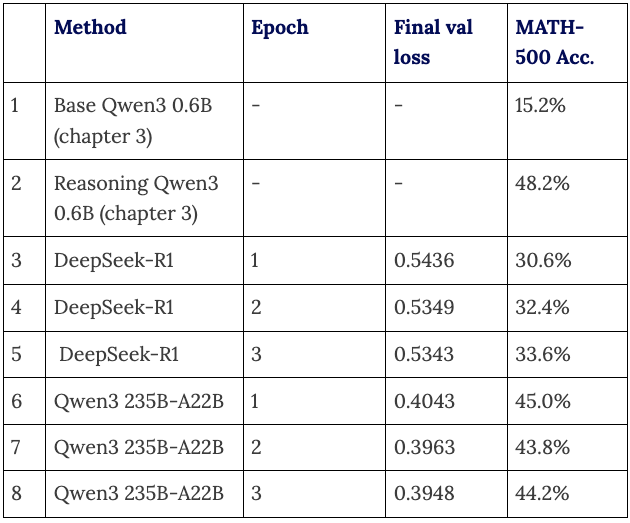